# crystalspec — formal figure set (figures 1-4)

Regenerates the four main-text spectroscopy figures from raw instrument data.
Plotting code lives in `figures_min.py` / `quantify_min.py` alongside this
notebook — a minimal extract of the full `crystalspec` package containing
only what these four figures need (see the module docstrings for what was
left out and why). Instrument-correction logic (scatter removal, spectrometer
reset stitching, dose calibration) is reused from the full package rather
than duplicated.

Captions are in `figure_1-4_captions.txt` in this directory.


In [ ]:
import sys, os

# Adjust these two paths if running outside the original project layout.
CRYSTALSPEC_SRC = os.path.abspath("../src")       # the full crystalspec package (instrument corrections, style)
RAW_DATA_DIR = os.path.abspath("../../crystalspec_data/HGD_nanospec/mx29074-47")
CONFIG_PATH = os.path.abspath("../config/experiment.toml")
OUT_DIR = os.path.abspath(".")

sys.path.insert(0, CRYSTALSPEC_SRC)
sys.path.insert(0, os.path.abspath("."))  # this directory, for figures_min/quantify_min

import numpy as np
import crystalspec.registry as Rg
import crystalspec.pipeline as Pl
import crystalspec.dose as Dm
import figures_min as F

print("modules loaded")

modules loaded


## Load and process raw data

One pass from raw `.asc` spectra to per-condition, dose-calibrated results — the same pipeline (scatter removal, reset stitching, dose model) used everywhere else in this project.

In [ ]:
registry = Rg.load_registry(CONFIG_PATH, raw_dir=RAW_DATA_DIR)
dose_model = Dm.DoseModel(dose_per_exposure_MGy=0.104181, exposure_s=0.1)
results = {key: Pl.process_condition(registry, key, dose_model) for key in registry.conditions}

for key, r in results.items():
    print(f"  {key:9s} {len(r.traces)} positions, to {r.max_valid_dose_MGy():.2f} MGy")

  DTNB_5    5 positions, to 5.00 MGy
  DTNB_25   5 positions, to 25.00 MGy
  DTNB_50   5 positions, to 6.77 MGy
  DTNB_100  5 positions, to 3.02 MGy
  apo_5     5 positions, to 4.91 MGy
  apo_10    5 positions, to 9.93 MGy
  apo_25    5 positions, to 23.34 MGy
  apo_50    5 positions, to 2.19 MGy
  apo_100   5 positions, to 2.08 MGy


## Figure 1 — original presentation, corrected

Difference spectra and diagnostic-wavelength traces for DTNB-soaked vs. apo
crystals, dose-referenced. See caption for the corrections applied relative
to the original analysis (wavelength floor, reset repair, dose vs. time axis,
matched control, optical-failure truncation).

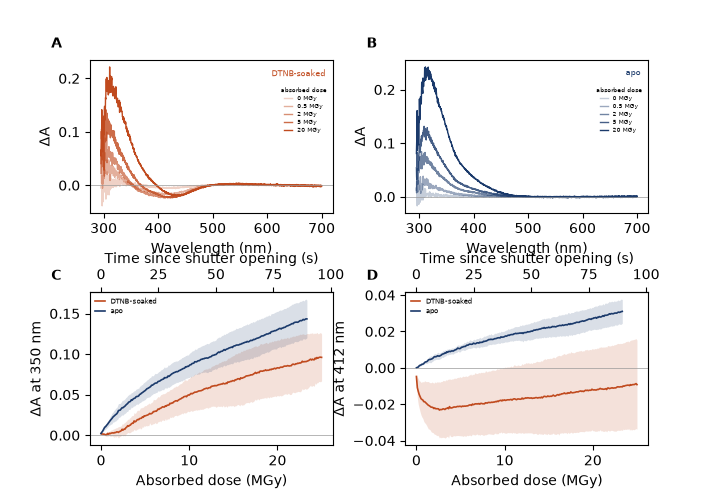

In [ ]:
fig1 = F.figure_original_idiom(results, os.path.join(OUT_DIR, "figure_1_spectra_and_traces.png"))
fig1

## Figure 2 — diagnostic wavelengths and D50/D90

Standard microspectrophotometry presentation: spectra, multi-wavelength
kinetics, and the 412 nm label-loss saturation fit (D50/D90) at all four
transmission settings.

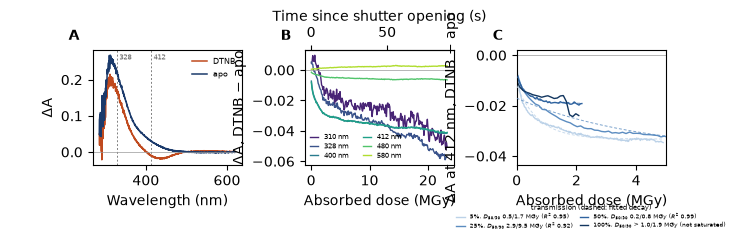

In [ ]:
fig2 = F.figure_diagnostic_wavelengths(results, os.path.join(OUT_DIR, "figure_2_diagnostic_wavelengths.png"))
fig2

## Figure 3 — experiment design / feasibility

Label loss against absorbed dose relative to a published room-temperature
crystal lifetime, and the detection-dose-to-lifetime ratio across dose
rates (single crystal vs. N-crystal averaging).

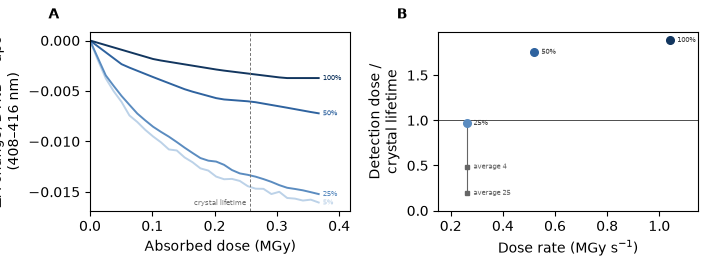

In [ ]:
fig3 = F.figure_experiment_design(results, os.path.join(OUT_DIR, "figure_3_experiment_design.png"))
fig3

## Figure 4 — room temperature vs. cryogenic

Difference spectra and label-band comparison between the room-temperature
multicrystal series and single-crystal 100 K cryogenic data.

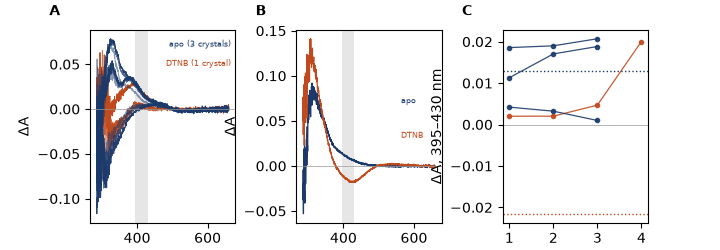

In [ ]:
fig4 = F.figure_cryo(registry, results, os.path.join(OUT_DIR, "figure_4_rt_vs_cryo.png"))
fig4

## Verification

Cross-check the D50/D90 values drawn in figure 2 against the full
`crystalspec.quantify.fit_single_exponential` / table 9, to confirm the
minimized code path reproduces the same numbers as the complete pipeline.

In [ ]:
from quantify_min import diagnostic_trace, fit_single_exponential

PAIRS = [("DTNB_5","apo_5"), ("DTNB_25","apo_25"), ("DTNB_50","apo_50"), ("DTNB_100","apo_100")]
for dk, ak in PAIRS:
    Dd, yd = diagnostic_trace(results[dk], 412.0, 4.0)
    Da, ya = diagnostic_trace(results[ak], 412.0, 4.0)
    dmax = min(results[dk].max_valid_dose_MGy(), results[ak].max_valid_dose_MGy())
    grid = np.linspace(0.0, dmax, 600)
    diff = np.interp(grid, Dd, yd) - np.interp(grid, Da, ya)
    f = fit_single_exponential(grid, diff, falling_segment_only=False)
    print(f"{dk}: D50={f['D50_MGy']:.3f} D90={f['D90_MGy']:.3f} "
          f"lower_bound={f['D90_is_lower_bound']} R2={f['R2_single']:.3f}")

DTNB_5: D50=0.517 D90=1.698 lower_bound=False R2=0.953
DTNB_25: D50=2.883 D90=9.506 lower_bound=False R2=0.919
DTNB_50: D50=0.245 D90=0.804 lower_bound=False R2=0.986
DTNB_100: D50=1.005 D90=1.861 lower_bound=True R2=0.748
